**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**Check file existent**

In [8]:
### List all benchmark CSV files
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "batches_dev")
txt_fname = "benchmark_motifscan*csv"
txt_fglob = file.path(txt_fdiry, txt_fname)
vec_txt_fpath = Sys.glob(txt_fglob)

for (txt_fpath in vec_txt_fpath){cat(basename(txt_fpath), "\n")}

benchmark_motifscan_base_numseq1000.csv 
benchmark_motifscan_base_numseq100.csv 
benchmark_motifscan_base_numseq200.csv 
benchmark_motifscan_base_numseq400.csv 
benchmark_motifscan_base_numseq600.csv 
benchmark_motifscan_base_numseq800.csv 
benchmark_motifscan_parallel_numseq1000.csv 
benchmark_motifscan_parallel_numseq100.csv 
benchmark_motifscan_parallel_numseq200.csv 
benchmark_motifscan_parallel_numseq400.csv 
benchmark_motifscan_parallel_numseq600.csv 
benchmark_motifscan_parallel_numseq800.csv 
benchmark_motifscan_serial_numseq1000.csv 
benchmark_motifscan_serial_numseq100.csv 
benchmark_motifscan_serial_numseq200.csv 
benchmark_motifscan_serial_numseq400.csv 
benchmark_motifscan_serial_numseq600.csv 
benchmark_motifscan_serial_numseq800.csv 


**Import data**

In [13]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "batches_dev")
txt_fname = "benchmark_motifscan*csv"
txt_fglob = file.path(txt_fdiry, txt_fname)

### get all benchmark CSV files
vec_txt_fpath = Sys.glob(txt_fglob)

### import tables
lst = lapply(vec_txt_fpath, function(txt_fpath){
    dat = read_csv(txt_fpath, show_col_types = FALSE)
    return(dat)
})
dat = bind_rows(lst)

### assign and show
dat_benchmark_runtime_import = dat
print(dim(dat))
fun_display_table(dat)

[1] 18  4


Mode,Num_Seq,Num_Core,Time_Seconds
base,1000,10,496.96
base,100,10,51.05
base,200,10,113.01
base,400,10,201.21
base,600,10,313.01
base,800,10,420.19
parallel,1000,10,13.54
parallel,100,10,1.56
parallel,200,10,2.88
parallel,400,10,5.99


In [14]:
### 
dat = dat_benchmark_runtime_import
dat = dat %>% dplyr::mutate(
    Method = dplyr::recode(
        Mode,
        "base"     = "Base (Pure Python)",
        "serial"   = "Serial (NumPy, 1 core)",
        "parallel" = "Parallel (NumPy, 10 cores)"
    )
)
### assign and show
dat_benchmark_runtime_arrange = dat
print(dim(dat))
fun_display_table(dat)

[1] 18  5


Mode,Num_Seq,Num_Core,Time_Seconds,Method
base,1000,10,496.96,Base (Pure Python)
base,100,10,51.05,Base (Pure Python)
base,200,10,113.01,Base (Pure Python)
base,400,10,201.21,Base (Pure Python)
base,600,10,313.01,Base (Pure Python)
base,800,10,420.19,Base (Pure Python)
parallel,1000,10,13.54,"Parallel (NumPy, 10 cores)"
parallel,100,10,1.56,"Parallel (NumPy, 10 cores)"
parallel,200,10,2.88,"Parallel (NumPy, 10 cores)"
parallel,400,10,5.99,"Parallel (NumPy, 10 cores)"


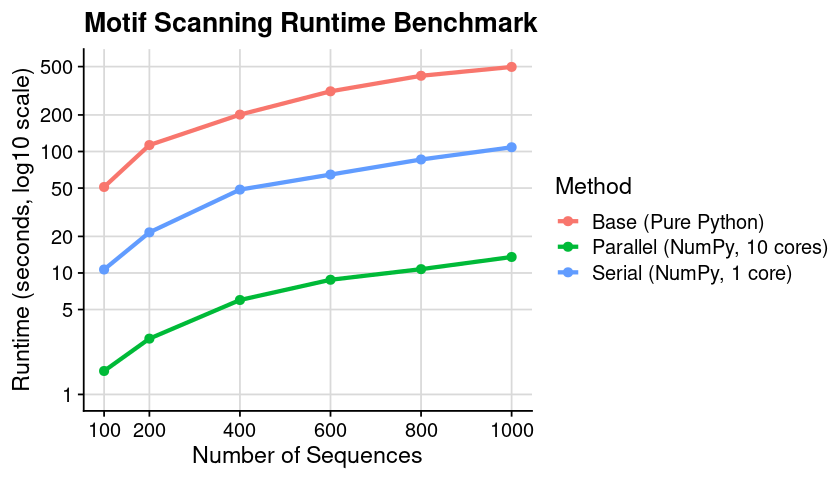

In [31]:
dat = dat_benchmark_runtime_arrange
gpt = ggplot(dat, aes(x = Num_Seq, y = Time_Seconds, color = Method)) +
    geom_line(linewidth = 1.2) +
    geom_point(size = 2) +
    scale_x_continuous(breaks = c(100, 200, 400, 600, 800, 1000)) +
    scale_y_continuous(
        breaks = c(1, 5, 10, 20, 50, 100, 200, 500),
        trans = "log10",
        limits = c(1, 510)
    ) +
    labs(
        title = "Motif Scanning Runtime Benchmark",
        x = "Number of Sequences",
        y = "Runtime (seconds, log10 scale)",
        color = "Method"
    ) +
    theme_cowplot() +
    background_grid()

options(repr.plot.height=4, repr.plot.width=7)
print(gpt)

In [41]:
dat = dat_benchmark_runtime_arrange
dat = dat %>%
    dplyr::select(Num_Seq, Mode, Time_Seconds) %>%
    tidyr::pivot_wider(names_from = Mode, values_from = Time_Seconds) %>%
    dplyr::mutate(
        Speedup_Serial   = base / serial,
        Speedup_Parallel = base / parallel
    ) %>%
    tidyr::pivot_longer(cols = starts_with("Speedup"), names_to = "Compare", values_to = "Speedup") %>%
    dplyr::mutate(
        Compare = recode(Compare,
            "Speedup_Serial"   = "Serial (vs Base)",
            "Speedup_Parallel" = "Parallel (vs Base)")
    )

dat_benchmark_speedup = dat
print(dim(dat))
head(dat)

[1] 12  6


Num_Seq,base,parallel,serial,Compare,Speedup
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1000,496.96,13.54,108.39,Serial (vs Base),4.584925
1000,496.96,13.54,108.39,Parallel (vs Base),36.703102
100,51.05,1.56,10.68,Serial (vs Base),4.779963
100,51.05,1.56,10.68,Parallel (vs Base),32.724359
200,113.01,2.88,21.59,Serial (vs Base),5.234368
200,113.01,2.88,21.59,Parallel (vs Base),39.239583


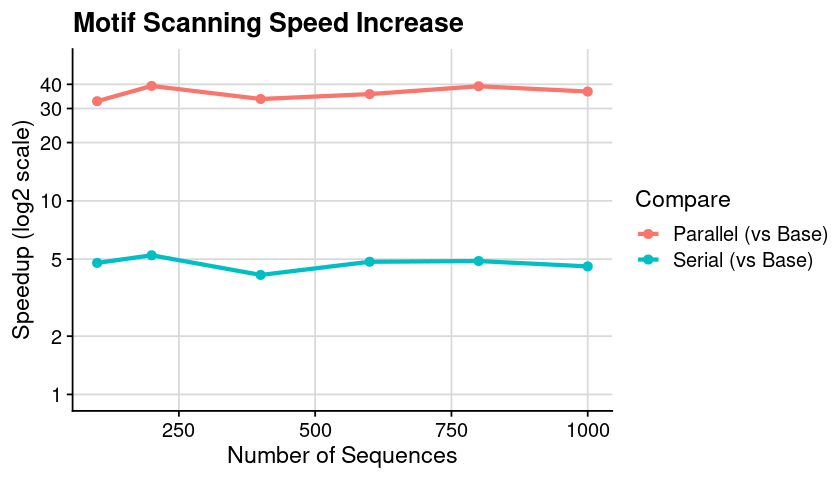

In [59]:
dat = dat_benchmark_speedup
gpt = ggplot(dat, aes(x = Num_Seq, y = Speedup, color = Compare)) +
    geom_line(linewidth = 1.2) +
    geom_point(size = 2) +
    scale_y_continuous(
        breaks = c(1, 2, 5, 10, 20, 30, 40),
        trans = "log2",
        limits = c(1, 50)
    ) +
    labs(
        title = "Motif Scanning Speed Increase",
        x = "Number of Sequences",
        y = "Speedup (log2 scale)",
        color = "Compare"
    ) +
    theme_cowplot() +
    background_grid()

options(repr.plot.height=4, repr.plot.width=7)
print(gpt)

**check data**

In [13]:
print(type(lst_seq_ref[0]))

<class 'Bio.SeqRecord.SeqRecord'>


In [ ]:
dplyr::mutate(
        Method = recode(<ethod,
                    "speedup_serial" = "Serial (vs Base)",
                    "speedup_parallel" = "Parallel (vs Base)")
  )